In [11]:
# import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

# gradient boosting libraries
import xgboost as xgb
# import lightgbm as lgb

In [2]:
# Load the dataset
data= pd.read_csv('Train_v2.csv')

In [ ]:
# take a look at the data
data.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
 13  loan_amount             23524 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 2.5+ MB


In [16]:
data.describe()

,year,household_size,age_of_respondent,loan_amount
count,23524.000000,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220,21785.360483
std,0.847371,2.227613,16.520569,14929.372574
min,2016.000000,1.000000,16.000000,6000.000000
25%,2016.000000,2.000000,26.000000,10585.000000
50%,2017.000000,3.000000,35.000000,17548.000000
75%,2018.000000,5.000000,49.000000,27837.000000
max,2018.000000,21.000000,100.000000,89891.000000


In [8]:
data.isnull().sum()*100/len(data)

country                   0.0
year                      0.0
uniqueid                  0.0
bank_account              0.0
location_type             0.0
cellphone_access          0.0
household_size            0.0
age_of_respondent         0.0
gender_of_respondent      0.0
relationship_with_head    0.0
marital_status            0.0
education_level           0.0
job_type                  0.0
dtype: float64

In [9]:
data.duplicated().sum()*100/len(data)

np.float64(0.0)

In [10]:
data.columns

Index(['country', 'year', 'uniqueid', 'bank_account', 'location_type',
       'cellphone_access', 'household_size', 'age_of_respondent',
       'gender_of_respondent', 'relationship_with_head', 'marital_status',
       'education_level', 'job_type'],
      dtype='object')

In [13]:

# Base loan amount
data["loan_amount"] = 5000

# Increase based on education
data.loc[data["education_level"] == "Secondary education", "loan_amount"] += 10000
data.loc[data["education_level"] == "Tertiary education", "loan_amount"] += 30000

# Increase based on job
data.loc[data["job_type"] == "Self employed", "loan_amount"] += 15000
data.loc[data["job_type"] == "Formally employed Private", "loan_amount"] += 25000

# Increase based on bank account
data.loc[data["bank_account"] == "Yes", "loan_amount"] += 20000

# Add randomness
data["loan_amount"] += np.random.randint(1000, 10000, size=len(data))

In [17]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical features:", numerical_features)

categorical_features = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_features)


Numerical features: ['year', 'household_size', 'age_of_respondent', 'loan_amount']
Categorical features: ['country', 'uniqueid', 'bank_account', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


# visualization 

# loan amount distribution 

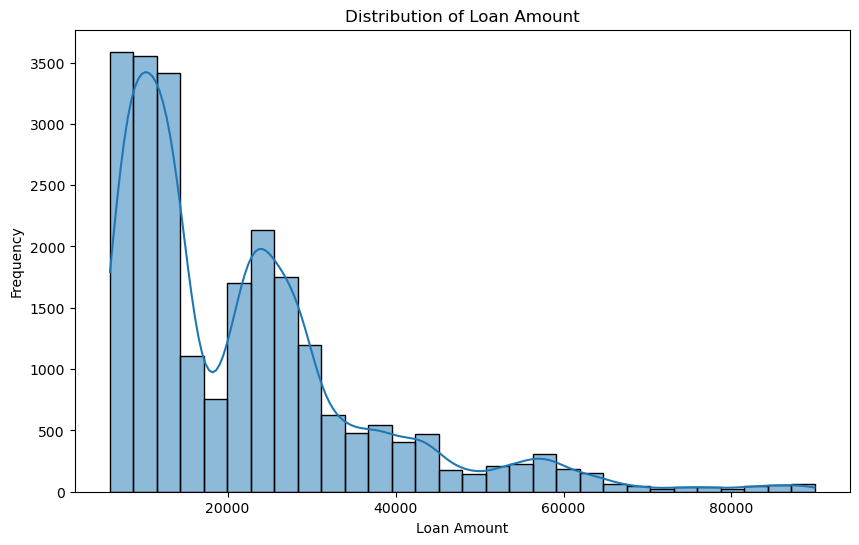

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data['loan_amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

# house size vs  loan amount 

Text(0, 0.5, 'House Size')

<Figure size 1000x600 with 0 Axes>

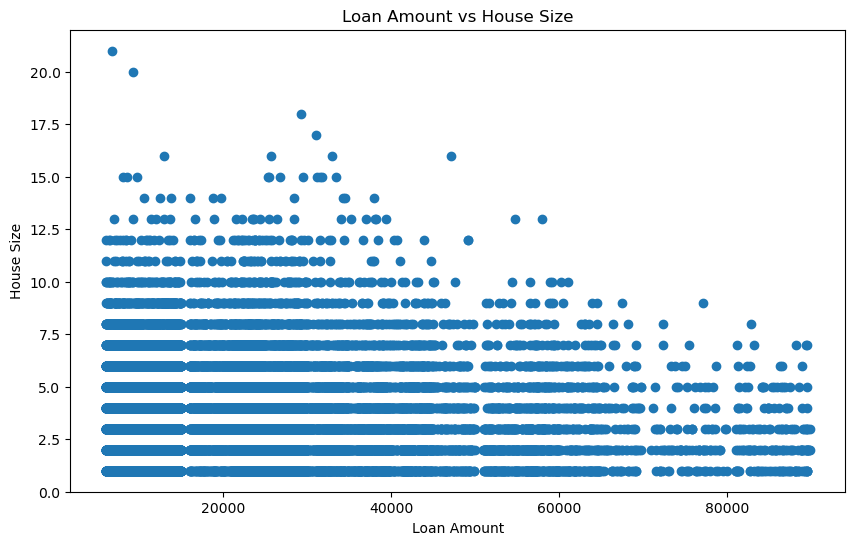

In [25]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.scatter(data['loan_amount'], data['household_size'])
plt.xlabel('Loan Amount')
plt.ylabel('Household Size')
plt.title('Loan Amount vs House Size')
plt.xlabel('Loan Amount')
plt.ylabel('House Size')   

<Figure size 1000x600 with 0 Axes>

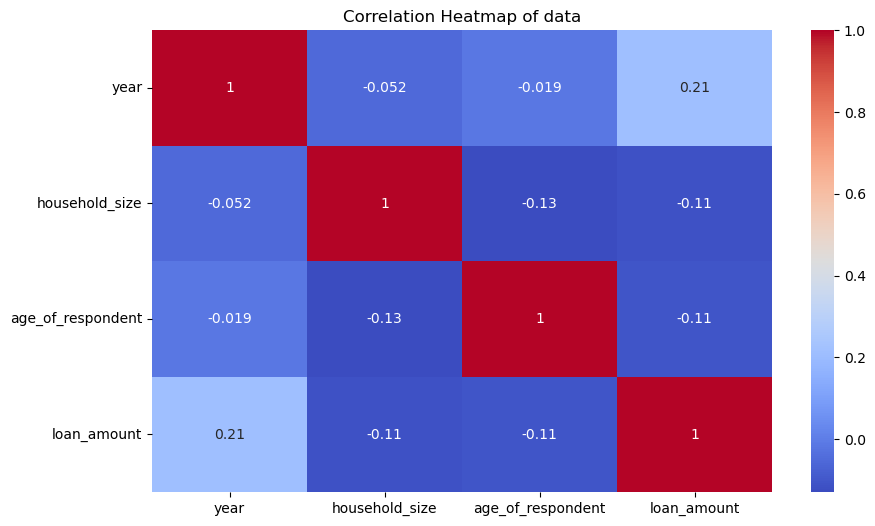

In [28]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of data')
plt.show()


# modeling

In [29]:
df.get_dummies(columns=categorical_features, drop_first=True, inplace=True)
x = df.drop(['loan_amount',"unique_id "], axis=1)
y = df['loan_amount']

AttributeError: 'DataFrame' object has no attribute 'get_dummies'

# ---1--- linear regression  base model

